In [ ]:
!mkdir -p ~/.kaggle



In [ ]:
!mv /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download arnavjain1/glaucoma-datasets

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
User cancelled operation


In [ ]:
ls

glaucoma-datasets.zip  sample_data/


In [ ]:
!unzip glaucoma-datasets.zip -d dataset/

Streaming output truncated to the last 5000 lines.
  inflating: dataset/REFUGE/test/Masks_Cropped/T0207.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0208.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0209.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0210.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0211.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0212.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0213.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0214.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0215.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0216.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0217.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0218.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0219.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0220.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0221.png  
  inflating: dataset/REFUGE/test/Masks_Cropped/T0222.png  
  inf

In [ ]:
ls

dataset/  glaucoma-datasets.zip  sample_data/


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
import cv2
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
DATASET_PATH = "/content/dataset/REFUGE"

In [ ]:
class RefugeeDataset:
    def __init__(self, images_dir, gts_dir):
        self.images_dir = images_dir
        self.gts_dir = gts_dir
        self.images = sorted(os.listdir(images_dir))
        self.gts = sorted(os.listdir(gts_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        gts_path = os.path.join(self.gts_dir, self.gts[idx])

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load Ground Truth Mask
        gts = cv2.imread(gts_path, cv2.IMREAD_UNCHANGED)

        # Convert RGB masks to grayscale if needed
        if len(gts.shape) == 3:
            gts = cv2.cvtColor(gts, cv2.COLOR_BGR2GRAY)

        # Debugging: Print unique values
        unique_values = np.unique(gts)
        print(f"Unique values in mask: {unique_values}")

        # **Correct Optic Disc Mask**
        optic_cup_mask = ((gts == 128) | (gts == 255)).astype(np.uint8)  # **Include both Disc & Cup**
        optic_disc_mask = (gts == 255).astype(np.uint8)  # Optic Cup only

        return image, optic_disc_mask, optic_cup_mask

In [ ]:
# Load dataset
dataset = RefugeeDataset(
    os.path.join(DATASET_PATH, "train/Images"),
    os.path.join(DATASET_PATH, "train/gts"),
)

In [ ]:
def visualize_samples(dataset, num_samples=5):
    fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples * 3))

    for i in range(num_samples):
        image, disc_mask, cup_mask = dataset[i]

        axs[i, 0].imshow(image)
        axs[i, 0].set_title("Input Image")
        axs[i, 0].axis("off")

        axs[i, 1].imshow(disc_mask, cmap="gray")
        axs[i, 1].set_title("Optic Disc Mask (128)")
        axs[i, 1].axis("off")

        axs[i, 2].imshow(cup_mask, cmap="gray")
        axs[i, 2].set_title("Optic Cup Mask (255)")
        axs[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

Unique values in mask: [  0 128 255]
Unique values in mask: [  0 128 255]
Unique values in mask: [  0 128 255]
Unique values in mask: [  0 128 255]
Unique values in mask: [  0 128 255]


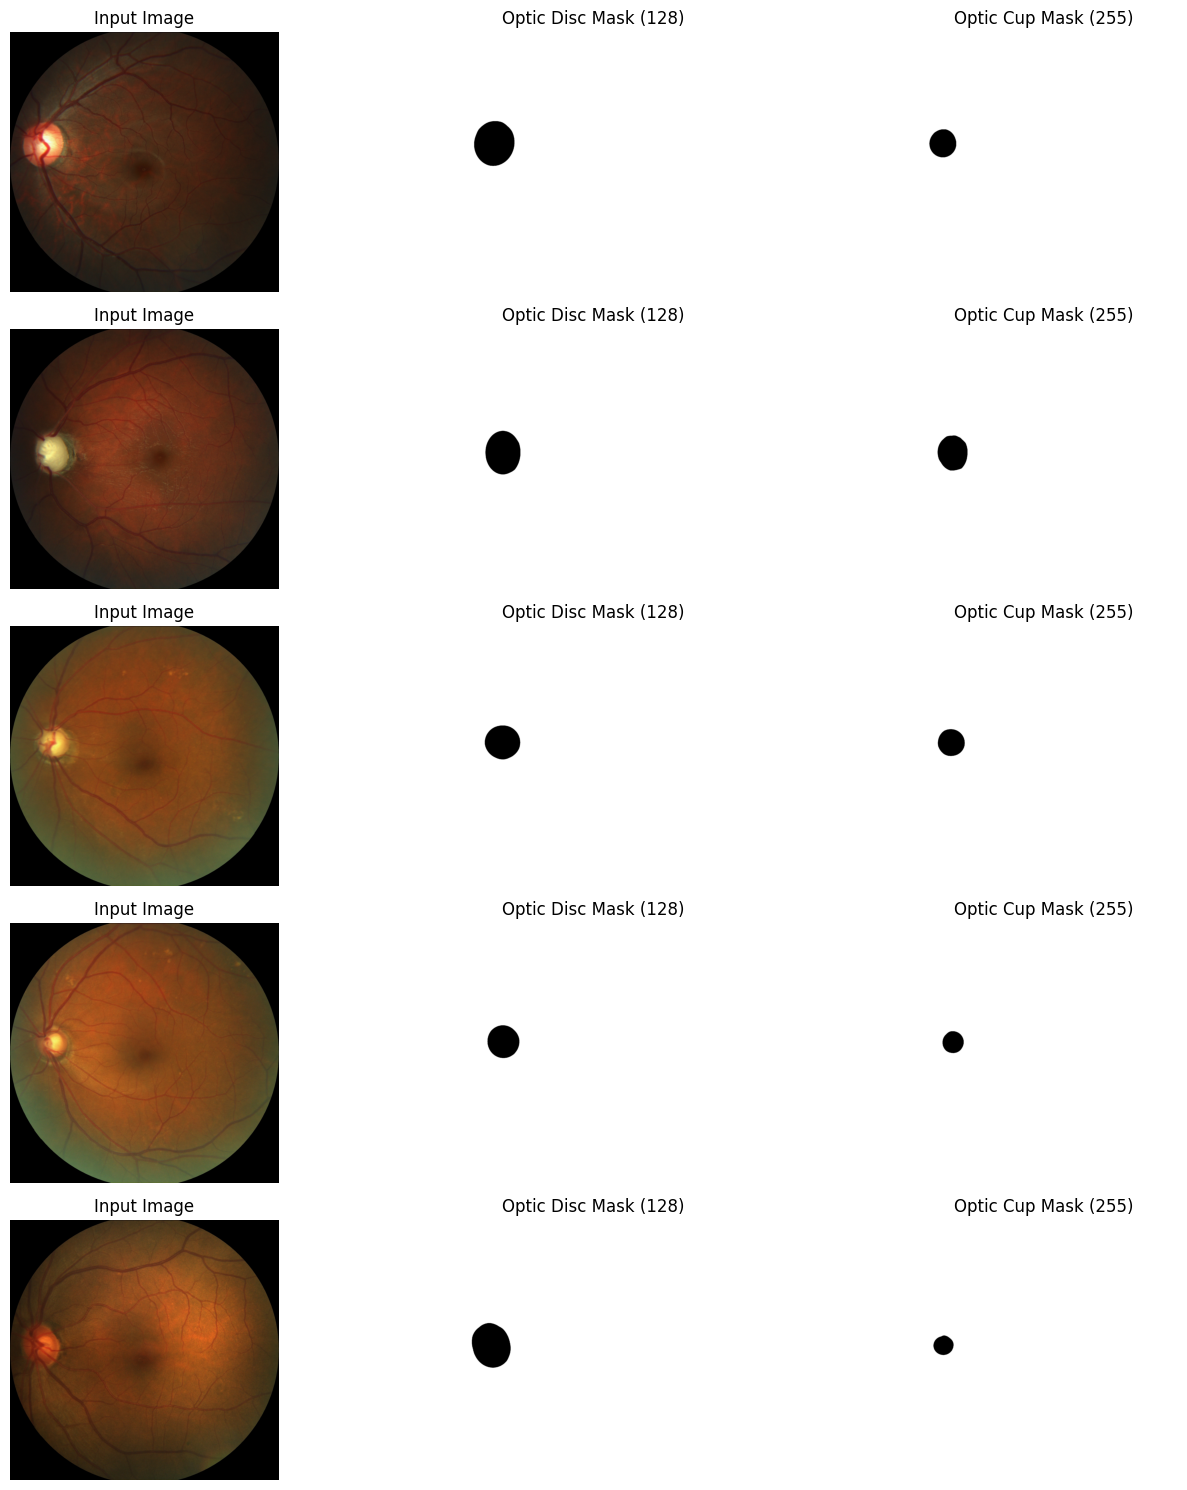

In [ ]:
visualize_samples(dataset, num_samples=5)

In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

class RefugeeDataset:
    def __init__(self, images_dir, gts_dir, transform=None):
        self.images_dir = images_dir
        self.gts_dir = gts_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.gts = sorted(os.listdir(gts_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        gts_path = os.path.join(self.gts_dir, self.gts[idx])

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load Ground Truth Mask
        gts = cv2.imread(gts_path, cv2.IMREAD_UNCHANGED)

        # Convert RGB masks to grayscale if needed
        if len(gts.shape) == 3:
            gts = cv2.cvtColor(gts, cv2.COLOR_BGR2GRAY)

        # Debugging: Print unique values
        unique_values = np.unique(gts)
      #  print(f"Unique values in mask: {unique_values}")

        # **Correct Optic Disc & Cup Masks**
        optic_cup_mask = ((gts == 128) | (gts == 255)).astype(np.uint8)  # **Disc includes Cup**
        optic_disc_mask = (gts == 255).astype(np.uint8)  # **Cup is inside Disc**

        # **Stack Masks for Multi-channel Support**
        mask = np.stack([optic_disc_mask, optic_cup_mask], axis=-1)  # Shape: (H, W, 2)

        # **Apply Transformations**
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

            # Convert mask back to (C, H, W) format for PyTorch
            mask = mask.permute(2, 0, 1)

        return image, mask

In [ ]:
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = RefugeeDataset(
    os.path.join(DATASET_PATH, "train/Images"),
    os.path.join(DATASET_PATH, "train/gts"),
    transform=transform
)
val_dataset = RefugeeDataset(
    os.path.join(DATASET_PATH, "val/Images"),
    os.path.join(DATASET_PATH, "val/gts"),
    transform=transform
)

In [ ]:
BATCH_SIZE = 8
EPOCHS = 15
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
import torch.nn.functional as F

class ResNetUNet(nn.Module):
    def __init__(self):
        super(ResNetUNet, self).__init__()
        base_model = models.resnet34(pretrained=True)
        self.base_layers = list(base_model.children())

        self.encoder = nn.Sequential(*self.base_layers[:6])  # Feature Extractor
        self.middle = nn.Sequential(*self.base_layers[6:8])  # Bottleneck

        self.up1 = self.upsample_block(512, 256)
        self.up2 = self.upsample_block(256, 128)
        self.up3 = self.upsample_block(128, 64)
        self.up4 = self.upsample_block(64, 32)

        self.final_conv = nn.Conv2d(32, 2, kernel_size=1)  # 2 Output Channels (Disc & Cup)

    def upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True),
        )

    def forward(self, x):
        enc_out = self.encoder(x)
        middle_out = self.middle(enc_out)

        up1 = self.up1(middle_out)
        up2 = self.up2(up1)
        up3 = self.up3(up2)
        up4 = self.up4(up3)

        output = self.final_conv(up4)

        # 🔥 **NEW FIX**: Upsample final output to match input size
        output = F.interpolate(output, size=(256, 256), mode="bilinear", align_corners=True)

        return torch.sigmoid(output)  # Sigmoid for Multi-Class Segmentation


In [ ]:
def dice_loss(pred, target, smooth=1e-5):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

In [ ]:
def train(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for images, masks in tqdm(dataloader):
        images, masks = images.to(DEVICE), masks.to(DEVICE).float()

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [ ]:
model = ResNetUNet().to(DEVICE)
criterion = CombinedLoss()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 153MB/s]


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR)

In [ ]:
for epoch in range(15):
    train_loss = train(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

100%|██████████| 50/50 [00:52<00:00,  1.04s/it]


Epoch 1/15, Train Loss: 0.0753


100%|██████████| 50/50 [00:50<00:00,  1.01s/it]


Epoch 2/15, Train Loss: 0.0318


100%|██████████| 50/50 [00:50<00:00,  1.01s/it]


...

Epoch 13/15, Train Loss: 0.0064


100%|██████████| 50/50 [00:50<00:00,  1.00s/it]


Epoch 14/15, Train Loss: 0.0059


100%|██████████| 50/50 [00:50<00:00,  1.01s/it]

Epoch 15/15, Train Loss: 0.0056


In [ ]:
torch.save(model.state_dict(), "resnet_unet_optic_disc_cup_fixed.pth")

In [ ]:
MODEL_PATH = "resnet_unet_optic_disc_cup_fixed.pth"  # Trained model
IMAGE_PATH = "/content/dataset/G1020/Images/image_1000.jpg"  # Change this to your test image path
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import torch

# Define model first
model = ResNetUNet()  # Ensure this matches the actual model used

# Load state dictionary
MODEL_PATH = "/content/resnet_unet_optic_disc_cup.pth"  # Update if needed
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))

# Move to device and set to eval mode
model.to(DEVICE).eval()

print("Model loaded successfully! ✅")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded successfully! ✅


<ipython-input-106-0627e0439f61>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))


In [ ]:
model.eval()

ResNetUNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [ ]:

import torchvision.transforms as transforms
def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256, 256))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    return transform(image).unsqueeze(0)

In [ ]:
def predict(image_path, model):
    image_tensor = preprocess_image(image_path).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)

    # Convert to NumPy
    pred_masks = output.cpu().squeeze(0).numpy()  # Shape: (2, 256, 256)

    # Thresholding (Convert probabilities to binary masks)
    optic_disc_pred = (pred_masks[0] > 0.5).astype(np.uint8)  # Optic Disc
    optic_cup_pred = (pred_masks[1] > 0.5).astype(np.uint8)   # Optic Cup

    return optic_disc_pred, optic_cup_pred


In [ ]:
def visualize_prediction(image_path, model):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (256, 256))

    optic_disc_pred, optic_cup_pred = predict(image_path, model)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(image_resized)
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    axs[1].imshow(optic_disc_pred, cmap="gray")
    axs[1].set_title("Predicted Optic Disc")
    axs[1].axis("off")

    axs[2].imshow(optic_cup_pred, cmap="gray")
    axs[2].set_title("Predicted Optic Cup")
    axs[2].axis("off")

    plt.show()

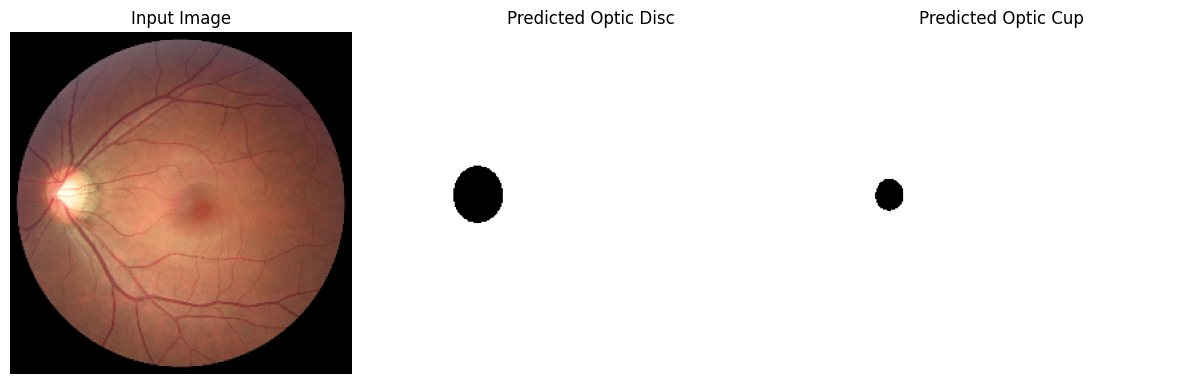

In [ ]:
visualize_prediction(IMAGE_PATH, model)

In [ ]:
TEST_IMAGES_DIR = "/content/dataset/REFUGE/test/Images"  # Folder with test images
SAVE_DIR = "/content/dataset/save_pred_masks"  # Folder to save predicted OD masks

In [ ]:
# Ensure save directory exists
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
def predict_and_save(image_path, save_path, model):
    image_tensor = preprocess_image(image_path).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)

    # Convert to NumPy
    pred_masks = output.cpu().squeeze(0).numpy()  # Shape: (2, 256, 256)

    # Extract optic disc mask (First channel)
    optic_disc_pred = (pred_masks[0] > 0.5).astype(np.uint8) * 255  # Convert to binary image

    # Save as PNG
    cv2.imwrite(save_path, optic_disc_pred)
    print(f"Saved: {save_path}")

In [ ]:
for img_file in os.listdir(TEST_IMAGES_DIR):
    img_path = os.path.join(TEST_IMAGES_DIR, img_file)
    save_path = os.path.join(SAVE_DIR, f"pred_{img_file}")

    predict_and_save(img_path, save_path, model)

Saved: /content/dataset/save_pred_masks/pred_T0192.jpg
Saved: /content/dataset/save_pred_masks/pred_T0358.jpg
Saved: /content/dataset/save_pred_masks/pred_T0353.jpg
Saved: /content/dataset/save_pred_masks/pred_T0205.jpg
Saved: /content/dataset/save_pred_masks/pred_T0393.jpg
Saved: /content/dataset/save_pred_masks/pred_T0049.jpg
Saved: /content/dataset/save_pred_masks/pred_T0283.jpg
Saved: /content/dataset/save_pred_masks/pred_T0148.jpg
Saved: /content/dataset/save_pred_masks/pred_T0292.jpg
Saved: /content/dataset/save_pred_masks/pred_T0321.jpg
Saved: /content/dataset/save_pred_masks/pred_T0199.jpg
Saved: /content/dataset/save_pred_masks/pred_T0031.jpg
Saved: /content/dataset/save_pred_masks/pred_T0339.jpg
Saved: /content/dataset/save_pred_masks/pred_T0166.jpg
Saved: /content/dataset/save_pred_masks/pred_T0128.jpg
Saved: /content/dataset/save_pred_masks/pred_T0171.jpg
Saved: /content/dataset/save_pred_masks/pred_T0182.jpg
Saved: /content/dataset/save_pred_masks/pred_T0322.jpg
Saved: /co

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

def dice_score(pred, target, smooth=1e-5):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(pred, target, smooth=1e-5):
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

def test_accuracy(model, test_loader, device):
    model.eval()
    dice_disc, dice_cup, iou_disc, iou_cup = [], [], [], []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Testing..."):
            images, masks = images.to(device), masks.to(device).float()

            outputs = model(images)
            preds = (outputs > 0.5).float()  # Convert to binary masks

            # Compute Dice and IoU scores for each class
            dice_disc.append(dice_score(preds[:, 0:1, :, :], masks[:, 0:1, :, :]))
            dice_cup.append(dice_score(preds[:, 1:2, :, :], masks[:, 1:2, :, :]))
            iou_disc.append(iou_score(preds[:, 0:1, :, :], masks[:, 0:1, :, :]))
            iou_cup.append(iou_score(preds[:, 1:2, :, :], masks[:, 1:2, :, :]))

    # Compute Mean Accuracy
    mean_dice_disc = np.mean(dice_disc)
    mean_dice_cup = np.mean(dice_cup)
    mean_iou_disc = np.mean(iou_disc)
    mean_iou_cup = np.mean(iou_cup)

    print(f"Dice Score - Optic Disc: {mean_dice_disc:.4f}")
    print(f"Dice Score - Optic Cup: {mean_dice_cup:.4f}")
    print(f"IoU Score - Optic Disc: {mean_iou_disc:.4f}")
    print(f"IoU Score - Optic Cup: {mean_iou_cup:.4f}")

    return mean_dice_disc, mean_dice_cup, mean_iou_disc, mean_iou_cup


In [ ]:
class RefugeeDataset(Dataset):
    def __init__(self, images_dir, gts_dir, transform=None):
        self.images_dir = images_dir
        self.gts_dir = gts_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.gts = sorted(os.listdir(gts_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        gts_path = os.path.join(self.gts_dir, self.gts[idx])

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))  # Ensure correct size

        # Convert to PyTorch tensor and normalize
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0  # (H, W, C) -> (C, H, W)

        # Load Ground Truth Mask
        gts = cv2.imread(gts_path, cv2.IMREAD_UNCHANGED)
        gts = cv2.resize(gts, (256, 256))

        # Convert RGB masks to grayscale if needed
        if len(gts.shape) == 3:
            gts = cv2.cvtColor(gts, cv2.COLOR_BGR2GRAY)

        # Extract Optic Disc (128) and Optic Cup (255)
        cup_mask = (gts == 128).astype(np.uint8)
        disc_mask = (gts == 255).astype(np.uint8)

        # Convert masks to PyTorch tensors
        mask = torch.tensor(np.stack([disc_mask, cup_mask], axis=0), dtype=torch.float32)  # (2, H, W)

        return image, mask


In [ ]:
# Define paths for test images and ground truth masks
TEST_IMAGES_DIR = "/content/dataset/REFUGE/test/Images"  # Path to test images
TEST_MASKS_DIR = "/content/dataset/REFUGE/test/gts"    # Path to corresponding ground truth masks

test_transform = None

# Create the test dataset
test_dataset = RefugeeDataset(images_dir=TEST_IMAGES_DIR, gts_dir=TEST_MASKS_DIR, transform=test_transform)

# Create DataLoader for test dataset
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


# Run test accuracy function
test_accuracy(model, test_loader, DEVICE)


Testing...: 100%|██████████| 50/50 [00:32<00:00,  1.53it/s]

Dice Score - Optic Disc: 0.9982
Dice Score - Optic Cup: 0.9990
IoU Score - Optic Disc: 0.9963
IoU Score - Optic Cup: 0.9980


(0.9981657946109772,
 0.9989920043945313,
 0.9963402056694031,
 0.9979869174957275)

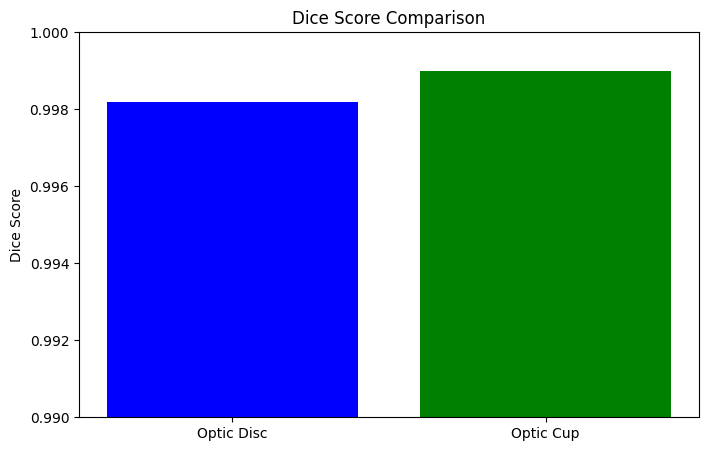

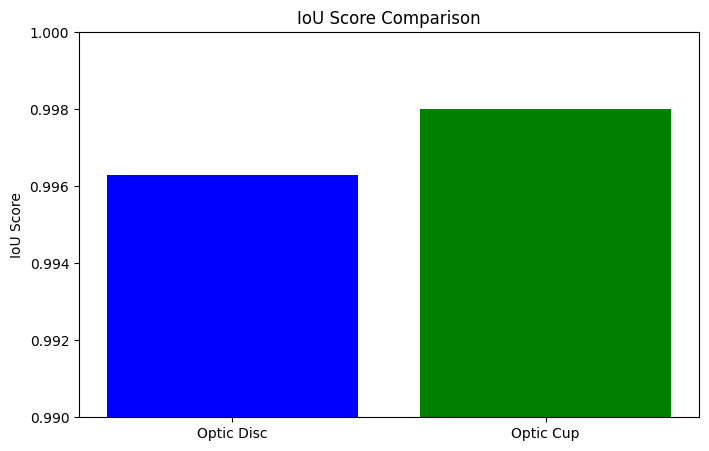

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
labels = ["Optic Disc", "Optic Cup"]
dice_scores = [0.9982, 0.9990]
iou_scores = [0.9963, 0.9980]

# Bar Plot for Dice Scores
plt.figure(figsize=(8,5))
plt.bar(labels, dice_scores, color=['blue', 'green'])
plt.ylim(0.99, 1.0)
plt.ylabel("Dice Score")
plt.title("Dice Score Comparison")
plt.show()

# Bar Plot for IoU Scores
plt.figure(figsize=(8,5))
plt.bar(labels, iou_scores, color=['blue', 'green'])
plt.ylim(0.99, 1.0)
plt.ylabel("IoU Score")
plt.title("IoU Score Comparison")
plt.show()


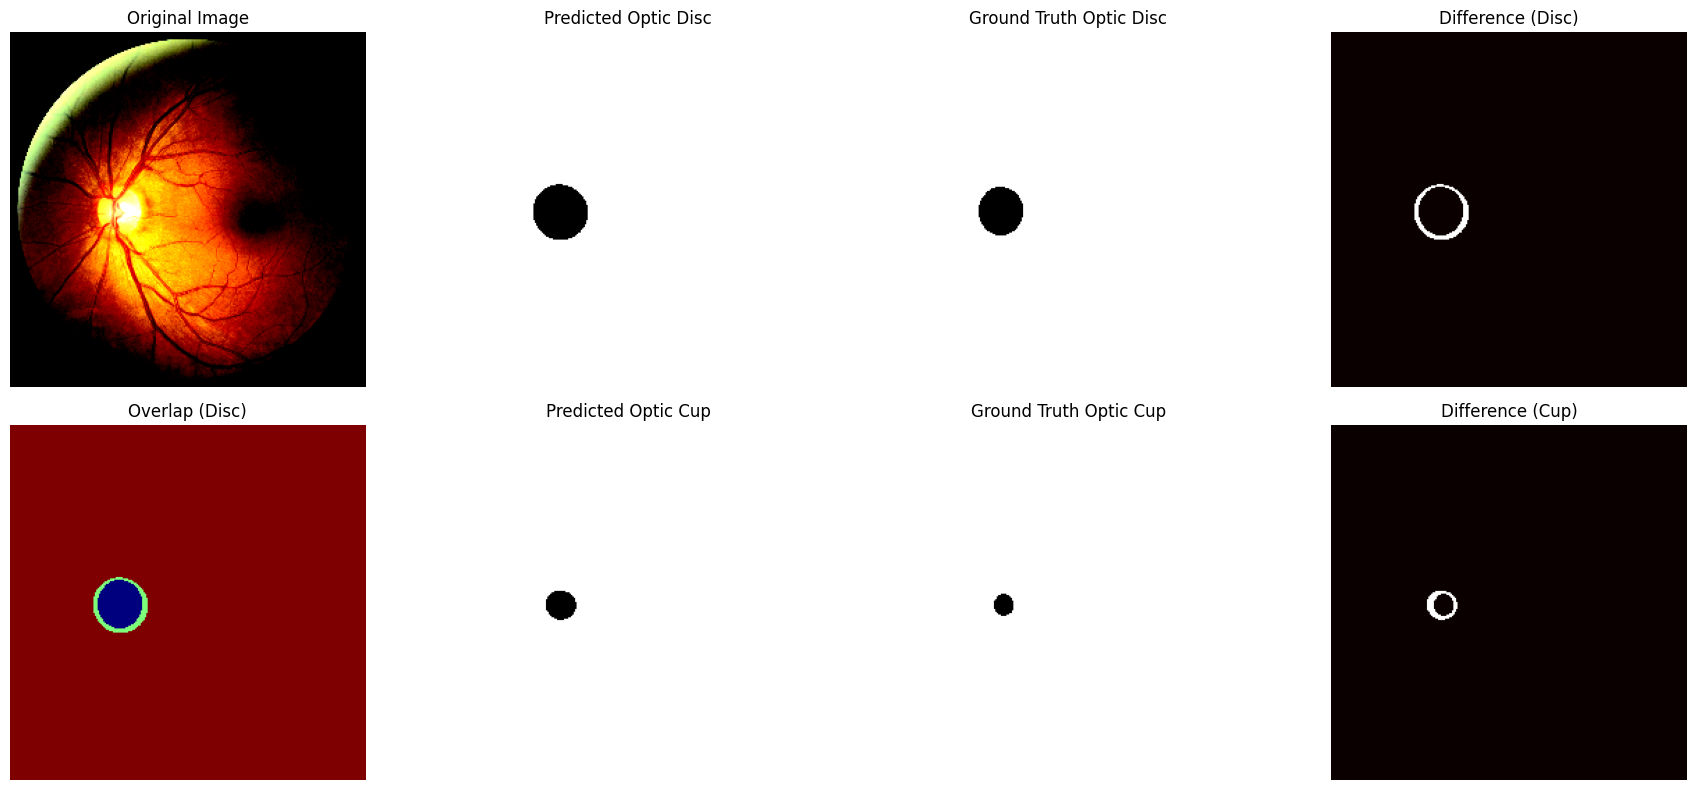

In [ ]:
# Load a sample from the dataset
image, gt_mask = val_dataset[10]  # Get input image and ground truth mask

# Generate prediction
with torch.no_grad():
    pred_mask = model(image.unsqueeze(0).to(DEVICE))  # Add batch dim
    pred_mask = (pred_mask > 0.5).float().squeeze(0)  # Threshold and remove batch dim

# **Visualize results**
visualize_segmentation(image, pred_mask, gt_mask)


In [ ]:
import numpy as np

def compute_cdr(pred_mask):

    # Convert to NumPy array if it's a tensor
    if isinstance(pred_mask, torch.Tensor):
        pred_mask = pred_mask.cpu().numpy()

    # Extract optic disc and cup masks
    optic_disc = pred_mask[1]  # Optic Disc Mask
    optic_cup = pred_mask[0]  # Optic Cup Mask

    # Compute areas
    disc_area = np.sum(optic_disc)
    cup_area = np.sum(optic_cup)

    # Compute CDR (handle zero division case)
    cdr = cup_area / disc_area if disc_area > 0 else 0
    return cdr


In [ ]:
# Load a sample from the dataset
image, gt_mask = val_dataset[30]  # Get input image and ground truth mask

# Generate prediction
with torch.no_grad():
    pred_mask = model(image.unsqueeze(0).to(DEVICE))  # Add batch dim
    pred_mask = (pred_mask > 0.5).float().squeeze(0)  # Threshold and remove batch dim

# **Compute CDR**
cdr_value = compute_cdr(pred_mask)
print(f"CDR Value: {cdr_value:.4f}")


CDR Value: 0.9878


In [ ]:
def classify_glaucoma(cdr):
    if cdr < 0.3:
        return "Normal ✅"
    elif 0.3 <= cdr < 0.4:
        return "Mild Glaucoma ⚠️"
    elif 0.4 <= cdr < 0.6:
        return "Moderate Glaucoma ⚠️"
    else:
        return "Severe Glaucoma 🚨"

print(f"Glaucoma Stage: {classify_glaucoma(cdr_value)}")


Glaucoma Stage: Severe Glaucoma 🚨
